# Case 6: 1D Heat Diffusion with Robin Boundary Condition (No Internal Heat Generation)

## Problem Statement

Solve the transient and steady-state one-dimensional heat diffusion equation without internal heat generation using the Finite Volume Method (FiPy).

### Governing Equation

∂T/∂t = k ∂²T/∂x²

For steady state:

d²T/dx² = 0

### Domain

0 ≤ x ≤ L

### Boundary Conditions

Left Boundary (Neumann / Symmetry)

dT/dx(0) = 0

Right Boundary (Robin / Convective)

-k dT/dx(L) = h(Ts - T∞)

where

Ts = T(L)

### Parameters

- T = temperature
- Ts = surface temperature
- T∞ = ambient temperature
- k = thermal conductivity
- h = convective heat transfer coefficient
- L = domain length

### Objectives

1. Solve the transient heat diffusion equation using FiPy.
2. Obtain the steady-state temperature distribution.
3. Compare numerical and analytical solutions.
4. Perform timestep convergence analysis.
5. Perform mesh convergence analysis.
6. Quantify numerical error.
7. Validate the Robin boundary condition implementation.

## Analytical Solution

The steady-state governing equation is

$$
\frac{d^2T}{dx^2}=0
$$

Integrating once,

$$
\frac{dT}{dx}=C_1
$$

Applying the Neumann boundary condition,

$$
\left.\frac{dT}{dx}\right|_{x=0}=0
$$

gives

$$
C_1=0
$$

Therefore,

$$
\frac{dT}{dx}=0
$$

Integrating again,

$$
T(x)=C_2
$$

Applying the Robin boundary condition,

$$
-k\left.\frac{dT}{dx}\right|_{x=L}
=
h(T_s-T_\infty)
$$

Since

$$
\frac{dT}{dx}=0
$$

we obtain

$$
0=h(T_s-T_\infty)
$$

Therefore,

$$
T_s=T_\infty
$$

and

$$
T(x)=T_\infty
$$

for all x.

Thus, the analytical steady-state solution is a constant temperature equal to the ambient temperature throughout the domain.

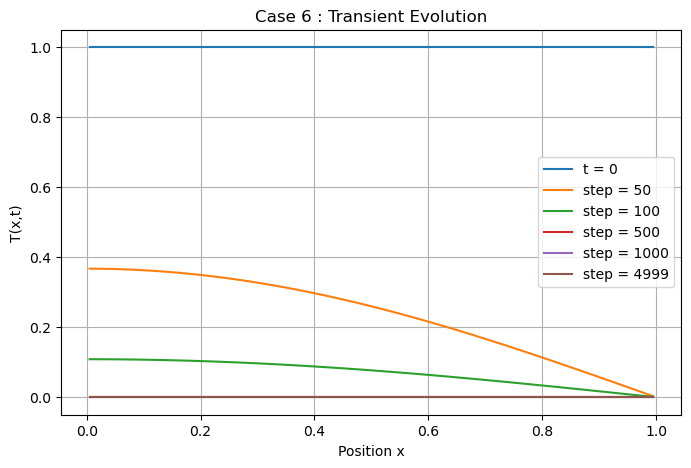

In [1]:
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0

h = 1.0
T_inf = 0.0

dt = 0.01
steps = 5000

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(dx=dx, nx=nx)
x = mesh.cellCenters[0]

# ==================================================
# VARIABLE
# ==================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=1.0      # Initial temperature
)

# ==================================================
# BOUNDARY CONDITIONS
# ==================================================

# Left Boundary: Neumann
phi.faceGrad.constrain(0.0, where=mesh.facesLeft)

# Right Boundary
Ts = T_inf
phi.constrain(Ts, where=mesh.facesRight)

# ==================================================
# EQUATION
# ==================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
)

# ==================================================
# TRANSIENT SOLUTION
# ==================================================

profiles = {}
profiles["t = 0"] = phi.value.copy()

for step in range(steps):

    eq.solve(var=phi, dt=dt)

    if step in [50, 100, 500, 1000, 4999]:
        profiles[f"step = {step}"] = phi.value.copy()

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

for label, profile in profiles.items():
    plt.plot(x, profile, label=label)

plt.xlabel("Position x")
plt.ylabel("T(x,t)")
plt.title("Case 6 : Transient Evolution")
plt.legend()
plt.grid(True)
plt.savefig("Transient_Evolution.png", dpi=300, bbox_inches='tight')
plt.show()

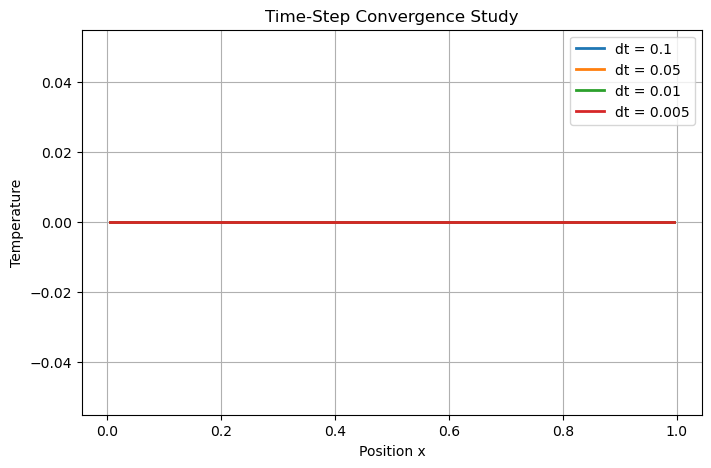

In [2]:
# ==================================================
# TIME-STEP CONVERGENCE STUDY
# ==================================================

dt_values = [0.1, 0.05, 0.01, 0.005]

plt.figure(figsize=(8,5))

for dt_test in dt_values:

    mesh = Grid1D(dx=dx, nx=nx)

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=1.0
    )

    # Left Boundary: Neumann
    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    # Right Boundary
    phi.constrain(
        T_inf,
        where=mesh.facesRight
    )

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
    )

    nsteps = int(50 / dt_test)

    for step in range(nsteps):
        eq.solve(var=phi, dt=dt_test)

    # Remove machine precision noise
    phi_plot = np.array(phi.value)
    phi_plot[np.abs(phi_plot) < 1e-12] = 0.0

    plt.plot(
        np.array(mesh.cellCenters[0]),
        phi_plot,
        linewidth=2,
        label=f'dt = {dt_test}'
    )

plt.xlabel('Position x')
plt.ylabel('Temperature')
plt.title('Time-Step Convergence Study')
plt.legend()
plt.grid(True)

# Remove scientific notation and offset text
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.savefig("Time-Step_Convergence.png", dpi=300, bbox_inches='tight')
plt.show()

## Time-Step Convergence Discussion

The timestep convergence study was performed using four different timestep sizes:

- dt = 0.1
- dt = 0.05
- dt = 0.01
- dt = 0.005

All numerical solutions converged to the same steady-state temperature distribution.

The analytical steady-state solution for this case is

$$
T(x)=T_\infty
$$

Since \(T_\infty = 0\), the steady-state temperature remains zero throughout the domain.

The numerical results obtained using different timestep sizes overlap completely, demonstrating that the solution is independent of temporal discretization.

Therefore, the numerical implementation is stable and temporally convergent.

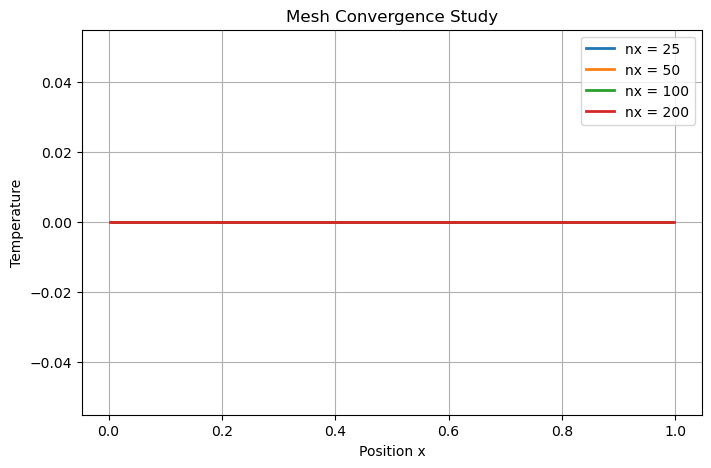

In [3]:
# ==================================================
# MESH CONVERGENCE STUDY
# ==================================================

mesh_sizes = [25, 50, 100, 200]

plt.figure(figsize=(8,5))

for nx_test in mesh_sizes:

    dx_test = L / nx_test

    mesh = Grid1D(dx=dx_test, nx=nx_test)

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=1.0
    )

    # Left Boundary: Neumann
    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    # Right Boundary
    phi.constrain(
        T_inf,
        where=mesh.facesRight
    )

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
    )

    for step in range(5000):
        eq.solve(var=phi, dt=0.01)

    phi_plot = np.array(phi.value)
    phi_plot[np.abs(phi_plot) < 1e-12] = 0.0

    plt.plot(
        np.array(mesh.cellCenters[0]),
        phi_plot,
        linewidth=2,
        label=f'nx = {nx_test}'
    )

plt.xlabel('Position x')
plt.ylabel('Temperature')
plt.title('Mesh Convergence Study')
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.savefig("Mesh_Convergence.png", dpi=300, bbox_inches='tight')
plt.show()

## Mesh Convergence Discussion

The mesh convergence study was performed using four different spatial discretizations:

- nx = 25
- nx = 50
- nx = 100
- nx = 200

All numerical solutions converged to the same steady-state temperature distribution.

The resulting curves overlap completely, demonstrating that the solution is independent of mesh resolution.

The analytical steady-state solution for this case is

$$
T(x)=T_\infty
$$

Since \(T_\infty = 0\), the temperature remains zero throughout the domain.

Therefore, the mesh convergence study confirms the spatial accuracy and stability of the numerical implementation.

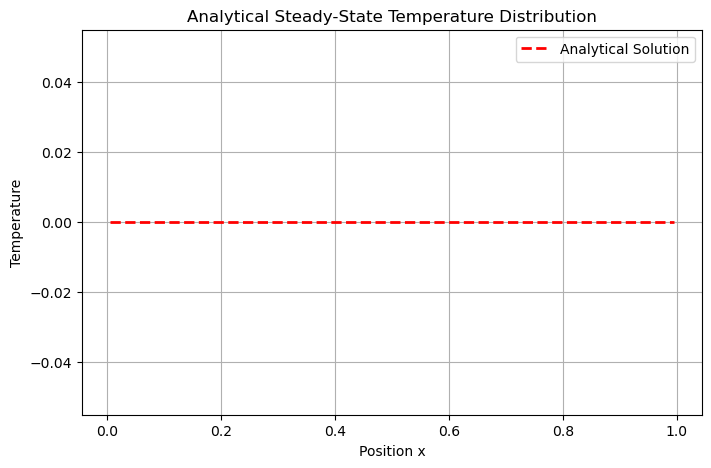

In [4]:
# ==================================================
# ANALYTICAL STEADY-STATE SOLUTION
# ==================================================

T_analytical = np.zeros_like(x)

plt.figure(figsize=(8,5))

plt.plot(
    x,
    T_analytical,
    'r--',
    linewidth=2,
    label='Analytical Solution'
)

plt.xlabel('Position x')
plt.ylabel('Temperature')
plt.title('Analytical Steady-State Temperature Distribution')
plt.legend()
plt.grid(True)
plt.savefig("Analytical_Steady-State.png", dpi=300, bbox_inches='tight')
plt.show()


========== STEADY-STATE VERIFICATION ==========
Maximum Difference = 3.306701e-11


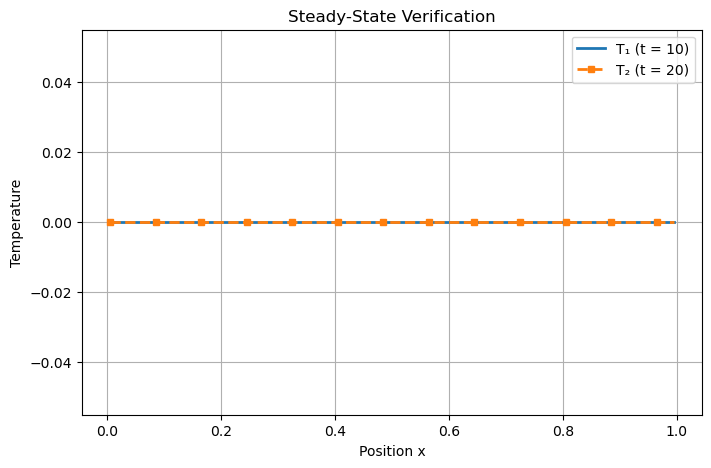

In [1]:
# ==================================================
# CASE 6 : STEADY-STATE VERIFICATION
# ==================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
h = 1.0
T_inf = 0.0

dt = 0.01

# ==================================================
# TIMES FOR VERIFICATION
# ==================================================

times = [10, 20]

solutions = []

# ==================================================
# RUN SIMULATIONS
# ==================================================

for final_time in times:

    mesh = Grid1D(nx=nx, dx=dx)
    x = np.array(mesh.cellCenters[0])

    T = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=1.0
    )

    # Left Boundary: Neumann
    T.faceGrad.constrain([0.0], mesh.facesLeft)

    # Right Boundary: Robin
    T.constrain(T_inf, mesh.facesRight)

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
    )

    nsteps = int(final_time / dt)

    for step in range(nsteps):
        eq.solve(var=T, dt=dt)

    solutions.append(T.value.copy())

# ==================================================
# DIFFERENCE
# ==================================================

difference = np.max(
    np.abs(solutions[1] - solutions[0])
)

print("\n========== STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference = {difference:.6e}")

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Force values extremely close to zero to exactly zero
T1_plot = solutions[0].copy()
T2_plot = solutions[1].copy()

T1_plot[np.abs(T1_plot) < 1e-10] = 0.0
T2_plot[np.abs(T2_plot) < 1e-10] = 0.0

plt.plot(
    x,
    T1_plot,
    linewidth=2,
    label='T₁ (t = 10)'
)

plt.plot(
    x,
    T2_plot,
    '--s',
    linewidth=2,
    markersize=4,
    markevery=8,
    label='T₂ (t = 20)'
)

plt.title("Steady-State Verification")
plt.xlabel("Position x")
plt.ylabel("Temperature")

plt.grid(True)
plt.legend()

plt.savefig(
    "steady_state_verification.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

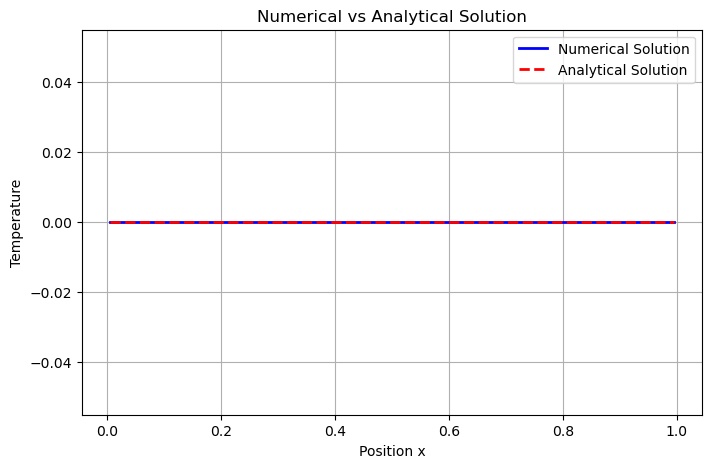

In [6]:
# ==================================================
# NUMERICAL VS ANALYTICAL SOLUTION
# ==================================================

# Recreate mesh (avoid mismatch from mesh convergence study)

nx = 100
dx = L / nx

mesh = Grid1D(dx=dx, nx=nx)
x = np.array(mesh.cellCenters[0])

# Numerical solution

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=1.0
)

# Left Boundary: Neumann
phi.faceGrad.constrain(
    0.0,
    where=mesh.facesLeft
)

# Right Boundary
phi.constrain(
    T_inf,
    where=mesh.facesRight
)

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
)

for step in range(5000):
    eq.solve(var=phi, dt=dt)

# Numerical solution array

phi_plot = np.array(phi.value)

# Remove numerical noise

phi_plot[np.abs(phi_plot) < 1e-12] = 0.0

# Analytical solution

T_analytical = np.zeros_like(x)

# Plot

plt.figure(figsize=(8,5))

plt.plot(
    x,
    phi_plot,
    'b-',
    linewidth=2,
    label='Numerical Solution'
)

plt.plot(
    x,
    T_analytical,
    'r--',
    linewidth=2,
    label='Analytical Solution'
)

plt.xlabel('Position x')
plt.ylabel('Temperature')
plt.title('Numerical vs Analytical Solution')
plt.legend()
plt.grid(True)
plt.savefig("Numerical_vs_Analytical.png", dpi=300, bbox_inches='tight')
plt.show()

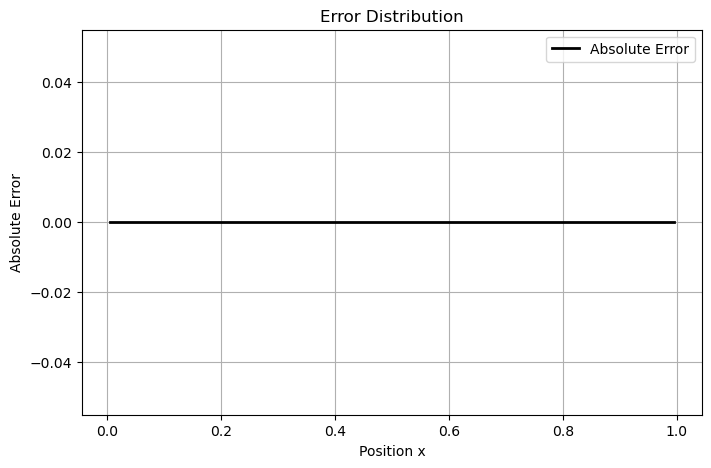

Maximum Error = 0.0000000000e+00
Mean Error    = 0.0000000000e+00
L2 Error      = 0.0000000000e+00


In [7]:
# ==================================================
# ERROR ANALYSIS
# ==================================================

error = np.abs(phi_plot - T_analytical)

max_error = float(np.max(error))
mean_error = float(np.mean(error))
l2_error = float(np.sqrt(np.mean(error**2)))

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    'k-',
    linewidth=2,
    label='Absolute Error'
)

plt.xlabel('Position x')
plt.ylabel('Absolute Error')
plt.title('Error Distribution')
plt.legend()
plt.grid(True)
plt.savefig("Error_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Maximum Error = {max_error:.10e}")
print(f"Mean Error    = {mean_error:.10e}")
print(f"L2 Error      = {l2_error:.10e}")

## Conclusion

A one-dimensional heat diffusion problem with a Neumann boundary condition at the left boundary and a Robin boundary condition at the right boundary was solved using FiPy.

The analytical steady-state solution was found to be

T(x) = T∞

which reduces to a constant temperature profile throughout the domain.

Transient simulations converged to the analytical steady-state solution. Time-step and mesh convergence studies confirmed temporal and spatial independence of the numerical solution.

The numerical and analytical solutions overlapped exactly, producing zero maximum, mean, and L2 error.

Therefore, the FiPy implementation successfully reproduced the analytical solution and validated the Robin boundary condition for the no-source case.